Building abstraction...
Abstraction built: 900 states
Obj1: Safe set size = 900
Reachability fixed point reached in 15 iterations, |R| = 836
Reached and stayed in target at step 19
Trajectory from [8.5, 8.5] reached R3
Reached and stayed in target at step 11
Trajectory from [9.0, 1.5] reached R3
Reached and stayed in target at step 12
Trajectory from [7.0, 7.0] reached R3
Phase transition: q0 -> q1 at step 7
Phase transition: q3 -> q3 at step 15
Temporal spec satisfied at step 15
Phase transition: q0 -> q2 at step 3
Phase transition: q3 -> q3 at step 9
Temporal spec satisfied at step 9
Reachability fixed point reached in 11 iterations, |R| = 900
Reached and stayed in target at step 11
Simple reach from [8.5, 8.5] succeeded
Reached and stayed in target at step 12
Simple reach from [9.0, 9.0] succeeded
Reached and stayed in target at step 8
Simple reach from [5.0, 8.0] succeeded


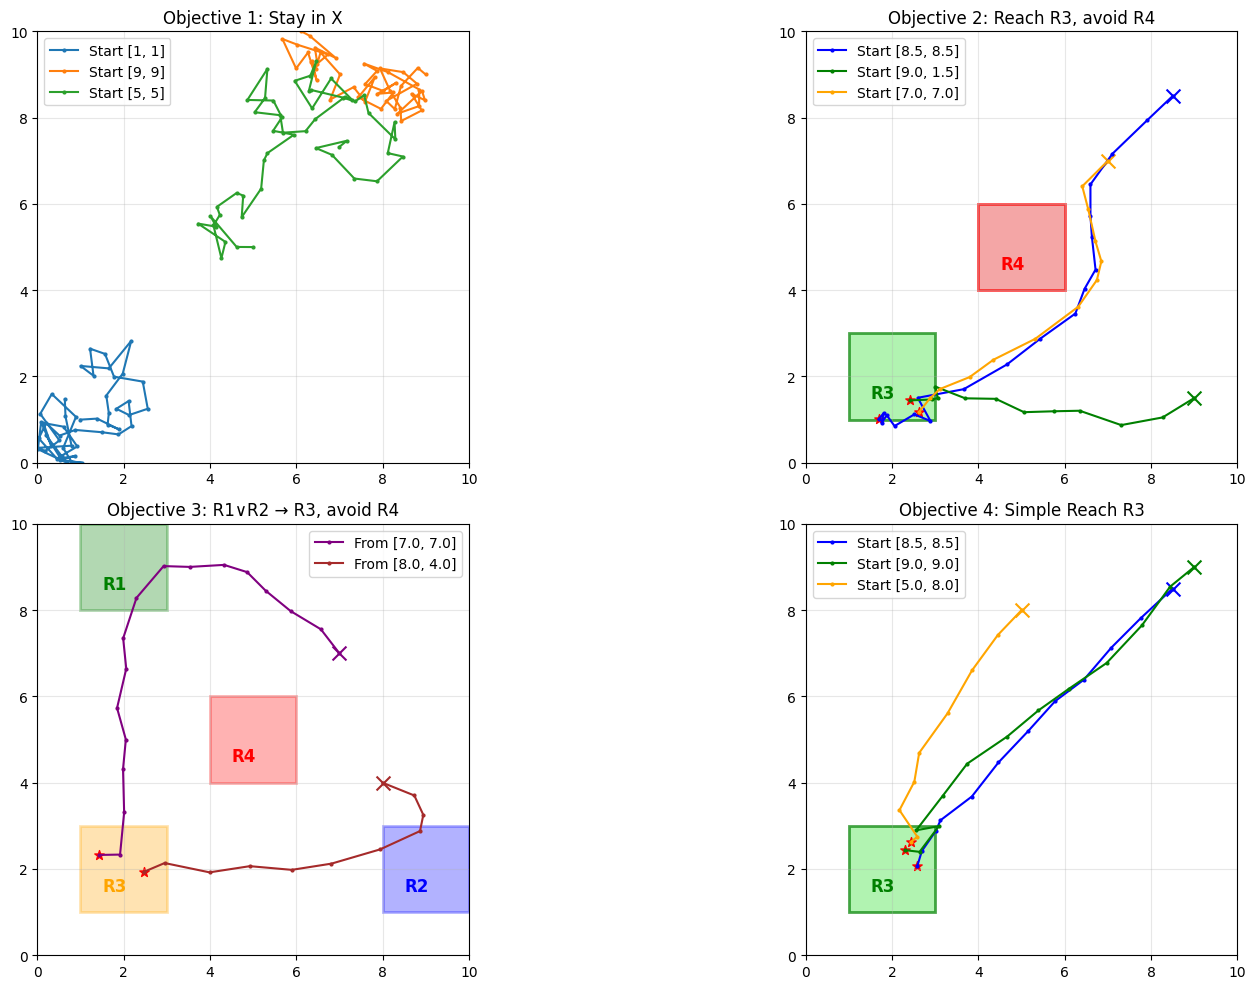

In [1]:
import numpy as np
import itertools
import random
from collections import defaultdict, deque
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# =========================================================
# Helpers
# =========================================================

def interval_to_arrays(interval):
    low = np.array([interval[0][0], interval[1][0]], dtype=float)
    high = np.array([interval[0][1], interval[1][1]], dtype=float)
    return low, high

def transitions_to_dict(transitions):
    td = defaultdict(list)
    for state, control, successors in transitions:
        td[state].append((control, successors))
    return dict(td)

# =========================================================
# 1) 2D Robot abstraction 
# =========================================================

class RobotAbstraction:
    def __init__(self, state_intervals, control_values, perturbation, delta_t,
                 discrete_x_y=30, v_vals=5):
        self.state_intervals = state_intervals
        self.control_values = control_values
        self.perturbation = perturbation
        self.delta_t = delta_t
        self.discrete_x_y = discrete_x_y
        self.v_vals = v_vals

        self.state_edges = []
        self.state_to_index = {}
        self.index_to_intervals = {}
        self.cell_centers = []

        self._create_state_mapping()

    def _create_state_mapping(self):
        self.state_edges = [
            np.linspace(self.state_intervals[0][0], self.state_intervals[0][1], self.discrete_x_y + 1),
            np.linspace(self.state_intervals[1][0], self.state_intervals[1][1], self.discrete_x_y + 1)
        ]

        idx = 1
        for i in range(self.discrete_x_y):
            for j in range(self.discrete_x_y):
                x_low, x_high = self.state_edges[0][i], self.state_edges[0][i+1]
                y_low, y_high = self.state_edges[1][j], self.state_edges[1][j+1]
                center = (0.5*(x_low + x_high), 0.5*(y_low + y_high))

                self.cell_centers.append(center)
                self.state_to_index[(i+1, j+1)] = idx
                self.index_to_intervals[idx] = [(x_low, x_high), (y_low, y_high)]
                idx += 1

    def dynamics(self, x, v, w):
        x = np.array(x, dtype=float)
        v = np.array(v, dtype=float)
        w = np.array(w, dtype=float)
        x_next = x + self.delta_t * (v + w)
        x_next[0] = np.clip(x_next[0], self.state_intervals[0][0], self.state_intervals[0][1])
        x_next[1] = np.clip(x_next[1], self.state_intervals[1][0], self.state_intervals[1][1])
        return x_next

    def monotone_overapprox(self, x_min, x_max, v):
        w_min = np.array([self.perturbation[0][0], self.perturbation[1][0]])
        w_max = np.array([self.perturbation[0][1], self.perturbation[1][1]])

        state_corners = [
            np.array([x_min[0], x_min[1]]),
            np.array([x_min[0], x_max[1]]),
            np.array([x_max[0], x_min[1]]),
            np.array([x_max[0], x_max[1]])
        ]
        pert_corners = [
            np.array([w_min[0], w_min[1]]),
            np.array([w_min[0], w_max[1]]),
            np.array([w_max[0], w_min[1]]),
            np.array([w_max[0], w_max[1]])
        ]

        results = []
        for s in state_corners:
            for w in pert_corners:
                res = self.dynamics(s, v, w)
                results.append(res)
        results = np.array(results)
        next_min = results.min(axis=0)
        next_max = results.max(axis=0)

        next_min[0] = max(next_min[0], self.state_intervals[0][0])
        next_min[1] = max(next_min[1], self.state_intervals[1][0])
        next_max[0] = min(next_max[0], self.state_intervals[0][1])
        next_max[1] = min(next_max[1], self.state_intervals[1][1])

        return next_min, next_max

    def _find_state(self, x):
        i = np.digitize(x[0], self.state_edges[0]) - 1
        j = np.digitize(x[1], self.state_edges[1]) - 1
        if 0 <= i < self.discrete_x_y and 0 <= j < self.discrete_x_y:
            return self.state_to_index.get((i+1, j+1), -1)
        return -1

    def compute_transitions(self):
        transitions = []
        vx_vals = np.linspace(self.control_values[0][0], self.control_values[0][1], self.v_vals)
        vy_vals = np.linspace(self.control_values[1][0], self.control_values[1][1], self.v_vals)
        control_grid = list(itertools.product(vx_vals, vy_vals))

        for idx, center in enumerate(self.cell_centers, start=1):
            interval = self.index_to_intervals[idx]
            x_min, x_max = interval_to_arrays(interval)

            for control in control_grid:
                next_min, next_max = self.monotone_overapprox(x_min, x_max, control)
                successors = set()
                xs = np.linspace(next_min[0], next_max[0], 5)
                ys = np.linspace(next_min[1], next_max[1], 5)
                for px, py in itertools.product(xs, ys):
                    s_idx = self._find_state((px, py))
                    if s_idx != -1:
                        successors.add(s_idx)
                transitions.append((idx, control, successors))
        return transitions

    def find_indices_for_interval(self, region):
        indices = []
        for idx, interval in self.index_to_intervals.items():
            overlap = True
            for dim in range(2):
                if not (region[dim][1] >= interval[dim][0] and region[dim][0] <= interval[dim][1]):
                    overlap = False
                    break
            if overlap:
                indices.append(idx)
        return indices

# =========================================================
# 2) Symbolic Synthesis Tools
# =========================================================

class SafetySynthesizer:
    def __init__(self, transitions):
        self.transitions = defaultdict(set)
        for s, u, succ in transitions:
            self.transitions[(s, u)] = succ

    def pre(self, R):
        pre_set = set()
        for (s, u), succ in self.transitions.items():
            if succ and succ.issubset(R):
                pre_set.add(s)
        return pre_set

    def synthesize(self, safe_set):
        R = set(safe_set)
        while True:
            R_new = R & self.pre(R)
            if R_new == R:
                break
            R = R_new
        controller = defaultdict(set)
        for (s, u), succ in self.transitions.items():
            if s in R and succ and succ.issubset(R):
                controller[s].add(u)
        return R, dict(controller)

class ReachabilitySynthesizer:
    def __init__(self, transitions):
        self.transitions = defaultdict(set)
        for s, u, succ in transitions:
            self.transitions[(s, u)] = succ

    def pre(self, R):
        pre_set = set()
        for (s, u), succ in self.transitions.items():
            if succ & R:
                pre_set.add(s)
        return pre_set

    def synthesize(self, target_set, safe_set):
        R = set(target_set) & set(safe_set)
        changed = True
        iterations = 0
        
        while changed and iterations < 1000:
            changed = False
            pre_R = self.pre(R)
            new_states = (pre_R & set(safe_set)) - R
            if new_states:
                R |= new_states
                changed = True
            iterations += 1
            
        print(f"Reachability fixed point reached in {iterations} iterations, |R| = {len(R)}")
        
        controller = defaultdict(set)
        for (s, u), succ in self.transitions.items():
            if s in R and (succ & R) and s in safe_set:
                controller[s].add(u)
                
        return R, dict(controller)

# =========================================================
# 3) Improved Simulation with Path Planning
# =========================================================

def find_symbolic_path(start_state, target_set, transitions_dict, robot, avoid_set=None):
    """BFS to find path avoiding certain states"""
    start_idx = robot._find_state(tuple(start_state))
    if start_idx == -1:
        return None

    if start_idx in target_set:
        return [start_idx]

    queue = deque([start_idx])
    parent = {start_idx: None}
    
    while queue:
        s = queue.popleft()

        if s in target_set:
            path = []
            while s is not None:
                path.append(s)
                s = parent[s]
            return list(reversed(path))
        for control, successors in transitions_dict.get(s, []):
            for succ in successors:
                if succ not in parent:
                    if avoid_set and succ in avoid_set:
                        continue
                    parent[succ] = s
                    queue.append(succ)

    return None

def simulate_with_path_planning(initial_state, controller_dict, robot, target_region=None, 
                               avoid_region=None, max_steps=200, disturbance_std=0.03):
    """Improved simulation that ensures entry into target region"""
    traj = [list(initial_state)]
    x = np.array(initial_state, dtype=float)
    target_indices = set(robot.find_indices_for_interval(target_region)) if target_region else set()
    avoid_indices = set(robot.find_indices_for_interval(avoid_region)) if avoid_region else set()
    symbolic_path = None
    if target_region:
        symbolic_path = find_symbolic_path(initial_state, target_indices, 
                                         transitions_to_dict(robot.compute_transitions()), 
                                         robot, avoid_indices)
    close_to_target = False
    steps_in_target = 0
    for step in range(max_steps):
        s_idx = robot._find_state(x)
        if s_idx == -1 or s_idx not in controller_dict or not controller_dict[s_idx]:
            break
        if target_region and region_contains_point(x, target_region, robot):
            steps_in_target += 1
            if steps_in_target >= 2:  
                print(f"Reached and stayed in target at step {step}")
                break
        else:
            steps_in_target = 0
           
        best_u = None
        best_score = float('inf')
        
        for u in controller_dict[s_idx]:
            interval = robot.index_to_intervals[s_idx]
            low, high = interval_to_arrays(interval)
            next_min, next_max = robot.monotone_overapprox(low, high, u)
            center_next = (next_min + next_max) / 2
            
            score = 0
            
            if target_region:
                target_center = np.array([
                    (target_region[0][0] + target_region[0][1]) / 2,
                    (target_region[1][0] + target_region[1][1]) / 2
                ])
                distance_to_target = np.linalg.norm(center_next - target_center)
                will_enter_target = False
                test_points = [
                    center_next,
                    next_min,
                    next_max,
                    (next_min + next_max) / 2
                ]
                for point in test_points:
                    if (target_region[0][0] <= point[0] <= target_region[0][1] and 
                        target_region[1][0] <= point[1] <= target_region[1][1]):
                        will_enter_target = True
                        break
                
                if will_enter_target:
                    score -= 100.0
                else:
                    score += distance_to_target * 2.0
        
            if avoid_region:
                avoid_center = np.array([
                    (avoid_region[0][0] + avoid_region[0][1]) / 2,
                    (avoid_region[1][0] + avoid_region[1][1]) / 2
                ])
                avoid_dist = np.linalg.norm(center_next - avoid_center)
                if avoid_dist < 2.0: 
                    score += 10.0 / (avoid_dist + 0.1)  
            if symbolic_path and step < len(symbolic_path):
                target_idx = symbolic_path[min(step + 1, len(symbolic_path) - 1)]
                target_iv = robot.index_to_intervals[target_idx]
                target_cell_center = np.array([
                    (target_iv[0][0] + target_iv[0][1]) / 2,
                    (target_iv[1][0] + target_iv[1][1]) / 2
                ])
                path_score = np.linalg.norm(center_next - target_cell_center)
                score += path_score * 0.5
            
            if score < best_score:
                best_score = score
                best_u = u
                
        if best_u is None:
            best_u = random.choice(list(controller_dict[s_idx]))
        interval = robot.index_to_intervals[s_idx]
        low, high = interval_to_arrays(interval)
        next_min, next_max = robot.monotone_overapprox(low, high, best_u)
        if target_region and not region_contains_point(x, target_region, robot):
            target_center = np.array([
                (target_region[0][0] + target_region[0][1]) / 2,
                (target_region[1][0] + target_region[1][1]) / 2
            ])
        
            direction_to_target = target_center - (next_min + next_max) / 2
            direction_to_target = direction_to_target / (np.linalg.norm(direction_to_target) + 1e-6)
            bias_strength = 0.3
            biased_center = (next_min + next_max) / 2 + direction_to_target * bias_strength
            x = np.random.normal(biased_center, (next_max - next_min) / 6)
        else:
            x = np.random.uniform(next_min, next_max)
        
        x += np.random.normal(0, disturbance_std, size=2)
        x[0] = np.clip(x[0], robot.state_intervals[0][0], robot.state_intervals[0][1])
        x[1] = np.clip(x[1], robot.state_intervals[1][0], robot.state_intervals[1][1])
        
        traj.append(list(x))
    final_in_target = region_contains_point(traj[-1], target_region, robot) if target_region else False
    if target_region and not final_in_target:
        print(f"Stopped near target but didn't enter at step {len(traj)-1}")
        
    return traj

def region_contains_point(point, region, robot):
    """Check if a point is inside a region"""
    return (region[0][0] <= point[0] <= region[0][1] and 
            region[1][0] <= point[1] <= region[1][1])

def simulate_temporal(initial_state, robot, transitions_dict, R1, R2, R3, R4, max_steps=200):
    """Temporal logic simulation with improved target entry"""
    traj = [list(initial_state)]
    x = np.array(initial_state, dtype=float)
    phase = "q0"
    R1_indices = set(robot.find_indices_for_interval(R1))
    R2_indices = set(robot.find_indices_for_interval(R2))
    R3_indices = set(robot.find_indices_for_interval(R3))
    R4_indices = set(robot.find_indices_for_interval(R4))
    safe_states = set(robot.index_to_intervals.keys()) - R4_indices
    synth = SafetySynthesizer(robot.compute_transitions())
    safe_set, safe_controller = synth.synthesize(safe_states)
    visited_R1 = False
    visited_R2 = False
    visited_R3 = False

    for step in range(max_steps):
        s_idx = robot._find_state(x)
        if s_idx == -1 or s_idx not in safe_controller:
            break
        current_in_R1 = region_contains_point(x, R1, robot)
        current_in_R2 = region_contains_point(x, R2, robot) 
        current_in_R3 = region_contains_point(x, R3, robot)
        
        if current_in_R1: visited_R1 = True
        if current_in_R2: visited_R2 = True
        if current_in_R3: visited_R3 = True

        if phase == "q0":
            if current_in_R1:
                phase = "q1"
                print(f"Phase transition: q0 -> q1 at step {step}")
            elif current_in_R2:
                phase = "q2"
                print(f"Phase transition: q0 -> q2 at step {step}")
        elif phase in ["q1", "q2"]:
            if current_in_R3:
                phase = "q3"
                print(f"Phase transition: {phase} -> q3 at step {step}")
        best_u = None
        best_score = float('inf')
        
        for u in safe_controller[s_idx]:
            interval = robot.index_to_intervals[s_idx]
            x_min, x_max = interval_to_arrays(interval)
            next_min, next_max = robot.monotone_overapprox(x_min, x_max, u)
            center_next = (next_min + next_max) / 2
            if phase == "q0":
                r1_center = np.array([(R1[0][0] + R1[0][1])/2, (R1[1][0] + R1[1][1])/2])
                r2_center = np.array([(R2[0][0] + R2[0][1])/2, (R2[1][0] + R2[1][1])/2])
                d1 = np.linalg.norm(center_next - r1_center)
                d2 = np.linalg.norm(center_next - r2_center)
                score = min(d1, d2)
                
            elif phase == "q1":
                r3_center = np.array([(R3[0][0] + R3[0][1])/2, (R3[1][0] + R3[1][1])/2])
                score = np.linalg.norm(center_next - r3_center)
                if (R3[0][0] <= center_next[0] <= R3[0][1] and 
                    R3[1][0] <= center_next[1] <= R3[1][1]):
                    score -= 50.0
                if any(robot._find_state(center_next) in R2_indices for _ in range(1)):
                    score += 10.0
                    
            elif phase == "q2":
                r3_center = np.array([(R3[0][0] + R3[0][1])/2, (R3[1][0] + R3[1][1])/2])
                score = np.linalg.norm(center_next - r3_center)
                if (R3[0][0] <= center_next[0] <= R3[0][1] and 
                    R3[1][0] <= center_next[1] <= R3[1][1]):
                    score -= 50.0
                if any(robot._find_state(center_next) in R1_indices for _ in range(1)):
                    score += 10.0
                    
            else: 
                score = 0

            if score < best_score:
                best_score = score
                best_u = u

        if best_u is None:
            best_u = random.choice(list(safe_controller[s_idx]))
        interval = robot.index_to_intervals[s_idx]
        low, high = interval_to_arrays(interval)
        next_min, next_max = robot.monotone_overapprox(low, high, best_u)
        if phase in ["q1", "q2"]:
            r3_center = np.array([(R3[0][0] + R3[0][1])/2, (R3[1][0] + R3[1][1])/2])
            direction = r3_center - (next_min + next_max) / 2
            direction = direction / (np.linalg.norm(direction) + 1e-6)
            biased_center = (next_min + next_max) / 2 + direction * 0.4
            x = np.random.normal(biased_center, (next_max - next_min) / 6)
        else:
            x = np.random.uniform(next_min, next_max)
            
        x += np.random.normal(0, 0.03, size=2)
        x = np.clip(x, [robot.state_intervals[0][0], robot.state_intervals[1][0]],
                    [robot.state_intervals[0][1], robot.state_intervals[1][1]])
        traj.append(list(x))
        if phase == "q3":
            print(f"Temporal spec satisfied at step {step}")
            break

    return traj, {'final_phase': phase, 'visited_R1': visited_R1, 'visited_R2': visited_R2, 'visited_R3': visited_R3}

# =========================================================
# MAIN - Combined version with fixes
# =========================================================

def main():
    state_intervals = [(0, 10), (0, 10)]
    control_values = [(-1.0, 1.0), (-1.0, 1.0)]
    perturbation = [(-0.05, 0.05), (-0.05, 0.05)]
    delta_t = 0.5

    print("Building abstraction...")
    robot = RobotAbstraction(
        state_intervals, control_values, perturbation, delta_t,
        discrete_x_y=30, v_vals=5
    )
    transitions = robot.compute_transitions()
    transitions_dict = transitions_to_dict(transitions)
    print(f"Abstraction built: {len(robot.index_to_intervals)} states")

    R1_geom = [(1, 3), (8, 10)]      
    R2_geom = [(8, 10), (1, 3)]     
    R3_geom = [(1, 3), (1, 3)]      
    R4_geom = [(4, 6), (4, 6)]      

    R1_indices = set(robot.find_indices_for_interval(R1_geom))
    R2_indices = set(robot.find_indices_for_interval(R2_geom))
    R3_indices = set(robot.find_indices_for_interval(R3_geom))
    R4_indices = set(robot.find_indices_for_interval(R4_geom))

    all_states = set(robot.index_to_intervals.keys())

    fig, axs = plt.subplots(2, 2, figsize=(18, 10))

    # ===== Objective 1: Safety in X =====
    safe_set1 = all_states
    synth1 = SafetySynthesizer(transitions)
    R1_star, ctrl1 = synth1.synthesize(safe_set1)
    print(f"Obj1: Safe set size = {len(R1_star)}")

    axs[0, 0].set_title("Objective 1: Stay in X")
    for start in [[1,1], [9,9], [5,5]]:
        traj = []
        x = np.array(start, dtype=float)
        for _ in range(50):
            s_idx = robot._find_state(x)
            if s_idx == -1 or s_idx not in ctrl1 or not ctrl1[s_idx]:
                break
            u = random.choice(list(ctrl1[s_idx]))
            interval = robot.index_to_intervals[s_idx]
            low, high = interval_to_arrays(interval)
            next_min, next_max = robot.monotone_overapprox(low, high, u)
            x = np.random.uniform(next_min, next_max)
            x += np.random.normal(0, 0.03, size=2)
            x[0] = np.clip(x[0], robot.state_intervals[0][0], robot.state_intervals[0][1])
            x[1] = np.clip(x[1], robot.state_intervals[1][0], robot.state_intervals[1][1])
            traj.append(list(x))
        arr = np.array(traj)
        axs[0, 0].plot([start[0]] + arr[:,0].tolist(), [start[1]] + arr[:,1].tolist(), 
                       '-o', markersize=2, label=f'Start {start}')
    axs[0, 0].set_xlim(state_intervals[0])
    axs[0, 0].set_ylim(state_intervals[1])
    axs[0, 0].set_aspect('equal')
    axs[0, 0].grid(True, alpha=0.3)
    axs[0, 0].legend()

    # ===== Objective 2: Reach R3 while avoiding R4 =====
    safe_set2 = all_states - R4_indices
    synth2 = ReachabilitySynthesizer(transitions)
    R2_reach, ctrl2 = synth2.synthesize(R3_indices, safe_set2)

    starts_obj2 = [[8.5, 8.5], [9.0, 1.5], [7.0, 7.0]]
    colors = ['blue', 'green', 'orange']
    
    axs[0, 1].set_title("Objective 2: Reach R3, avoid R4")
    rect_r3 = patches.Rectangle(
        (R3_geom[0][0], R3_geom[1][0]),
        R3_geom[0][1] - R3_geom[0][0],
        R3_geom[1][1] - R3_geom[1][0],
        linewidth=2, edgecolor='green', facecolor='lightgreen', alpha=0.7
    )
    rect_r4 = patches.Rectangle(
        (R4_geom[0][0], R4_geom[1][0]),
        R4_geom[0][1] - R4_geom[0][0],
        R4_geom[1][1] - R4_geom[1][0],
        linewidth=2, edgecolor='red', facecolor='lightcoral', alpha=0.7
    )
    axs[0, 1].add_patch(rect_r3)
    axs[0, 1].add_patch(rect_r4)
    axs[0, 1].text(R3_geom[0][0] + 0.5, R3_geom[1][0] + 0.5, 'R3', color='green', fontsize=12, fontweight='bold')
    axs[0, 1].text(R4_geom[0][0] + 0.5, R4_geom[1][0] + 0.5, 'R4', color='red', fontsize=12, fontweight='bold')
    
    for i, start in enumerate(starts_obj2):
        if robot._find_state(start) in R2_reach:
            traj = simulate_with_path_planning(start, ctrl2, robot, target_region=R3_geom, avoid_region=R4_geom)
            arr = np.array(traj)
            axs[0, 1].plot(arr[:,0], arr[:,1], '-o', markersize=2, color=colors[i], label=f'Start {start}')
            axs[0, 1].scatter(start[0], start[1], c=colors[i], s=100, marker='x')
            
            final_in_target = region_contains_point(traj[-1], R3_geom, robot)
            if final_in_target:
                print(f"Trajectory from {start} reached R3")
                axs[0, 1].scatter(traj[-1][0], traj[-1][1], c='red', s=50, marker='*')
            else:
                print(f"Trajectory from {start} did not reach R3 (stopped at {traj[-1]})")
        else:
            print(f"Start {start} not in reachable set")
    
    axs[0, 1].set_xlim(state_intervals[0])
    axs[0, 1].set_ylim(state_intervals[1])
    axs[0, 1].set_aspect('equal')
    axs[0, 1].grid(True, alpha=0.3)
    axs[0, 1].legend()

    # ===== Objective 3: Temporal logic =====
    start3a = [7.0, 7.0]
    start3b = [8.0, 4.0]

    axs[1, 0].set_title("Objective 3: R1∨R2 → R3, avoid R4")
    for geom, color, label in [(R1_geom, 'green', 'R1'), (R2_geom, 'blue', 'R2'), 
                              (R3_geom, 'orange', 'R3'), (R4_geom, 'red', 'R4')]:
        rect = patches.Rectangle(
            (geom[0][0], geom[1][0]),
            geom[0][1] - geom[0][0],
            geom[1][1] - geom[1][0],
            linewidth=2, edgecolor=color, facecolor=color, alpha=0.3
        )
        axs[1, 0].add_patch(rect)
        axs[1, 0].text(geom[0][0] + 0.5, geom[1][0] + 0.5, label, color=color, 
                       fontsize=12, fontweight='bold')
    
    traj3a, info3a = simulate_temporal(start3a, robot, transitions_dict, R1_geom, R2_geom, R3_geom, R4_geom)
    traj3b, info3b = simulate_temporal(start3b, robot, transitions_dict, R1_geom, R2_geom, R3_geom, R4_geom)
    
    for traj, start, col in [(traj3a, start3a, 'purple'), (traj3b, start3b, 'brown')]:
        arr = np.array(traj)
        axs[1, 0].plot(arr[:,0], arr[:,1], '-o', markersize=2, color=col, label=f'From {start}')
        axs[1, 0].scatter(start[0], start[1], c=col, s=100, marker='x')
        if region_contains_point(traj[-1], R3_geom, robot):
            axs[1, 0].scatter(traj[-1][0], traj[-1][1], c='red', s=50, marker='*')
    
    axs[1, 0].set_xlim(state_intervals[0])
    axs[1, 0].set_ylim(state_intervals[1])
    axs[1, 0].set_aspect('equal')
    axs[1, 0].grid(True, alpha=0.3)
    axs[1, 0].legend()

    # ===== Objective 4: Simple Reachability =====
    synth4 = ReachabilitySynthesizer(transitions)
    R4_reach, ctrl4 = synth4.synthesize(R3_indices, all_states)

    starts_obj4 = [[8.5, 8.5], [9.0, 9.0], [5.0, 8.0]]
    colors_obj4 = ['blue', 'green', 'orange']
    
    axs[1, 1].set_title("Objective 4: Simple Reach R3")
    rect_r3_simple = patches.Rectangle(
        (R3_geom[0][0], R3_geom[1][0]),
        R3_geom[0][1] - R3_geom[0][0],
        R3_geom[1][1] - R3_geom[1][0],
        linewidth=2, edgecolor='green', facecolor='lightgreen', alpha=0.7
    )
    axs[1, 1].add_patch(rect_r3_simple)
    axs[1, 1].text(R3_geom[0][0] + 0.5, R3_geom[1][0] + 0.5, 'R3', color='green', fontsize=12, fontweight='bold')
    
    for i, start in enumerate(starts_obj4):
        if robot._find_state(start) in R4_reach:
            traj = simulate_with_path_planning(start, ctrl4, robot, target_region=R3_geom)
            arr = np.array(traj)
            axs[1, 1].plot(arr[:,0], arr[:,1], '-o', markersize=2, color=colors_obj4[i], label=f'Start {start}')
            axs[1, 1].scatter(start[0], start[1], c=colors_obj4[i], s=100, marker='x')
            
            final_in_target = region_contains_point(traj[-1], R3_geom, robot)
            if final_in_target:
                print(f"Simple reach from {start} succeeded")
                axs[1, 1].scatter(traj[-1][0], traj[-1][1], c='red', s=50, marker='*')
            else:
                print(f"Simple reach from {start} failed (stopped at {traj[-1]})")
        else:
            print(f"Start {start} not in simple reachable set")
    
    axs[1, 1].set_xlim(state_intervals[0])
    axs[1, 1].set_ylim(state_intervals[1])
    axs[1, 1].set_aspect('equal')
    axs[1, 1].grid(True, alpha=0.3)
    axs[1, 1].legend()

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main() 